<a href="https://colab.research.google.com/github/KBCoronado/MachineLearning/blob/main/Unidad4/Practica_2_Clustering_de_Frutas_con_K_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn import cluster
from sklearn.cluster import KMeans
from pandas._libs.tslibs.timedeltas import Components
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt
import numpy as np
frutas = pd.read_csv("fruit_data_with_colors.csv")
frutas.head()

,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.4,7.3,0.55
1,1,apple,granny_smith,180,8.0,6.8,0.59
2,1,apple,granny_smith,176,7.4,7.2,0.60
3,2,mandarin,mandarin,86,6.2,4.7,0.80
4,2,mandarin,mandarin,84,6.0,4.6,0.79


In [60]:
features = ['mass', 'width', 'height', 'color_score']
x = frutas[features]
x.head()

,mass,width,height,color_score
0,192,8.4,7.3,0.55
1,180,8.0,6.8,0.59
2,176,7.4,7.2,0.60
3,86,6.2,4.7,0.80
4,84,6.0,4.6,0.79


In [61]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

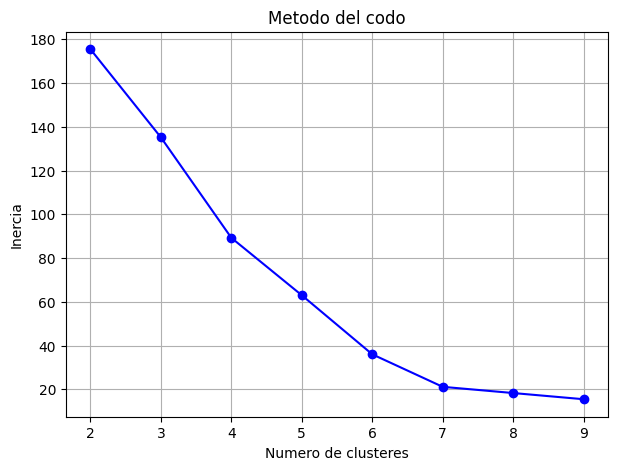

In [62]:
#Se determina el numero de clusteres (metodo del codo)
inertias = []
K = range(2, 10)
for k in K:
  km = KMeans(n_clusters=k, random_state=42)
  km.fit(x_scaled)
  inertias.append(km.inertia_)
plt.figure(figsize=(7,5))
plt.plot(K, inertias, "bo-")
plt.title("Metodo del codo")
plt.xlabel("Numero de clusteres")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()

In [63]:
#Aplicamos K-Meas con el valor elegido (4)
k = 4
Kmeans = KMeans(n_clusters=k, random_state=42)
cluster = Kmeans.fit_predict(x_scaled)
frutas ["cluster"] = cluster
print("\nDistribucion de frutas antes de PCA:")
print(frutas.groupby("fruit_name").size())
print("\nDistribucion de frutas por cluster:")
print(frutas.groupby("cluster").size())


Distribucion de frutas antes de PCA:
fruit_name
apple       19
lemon       16
mandarin     5
orange      19
dtype: int64

Distribucion de frutas por cluster:
cluster
0    22
1    19
2     5
3    13
dtype: int64


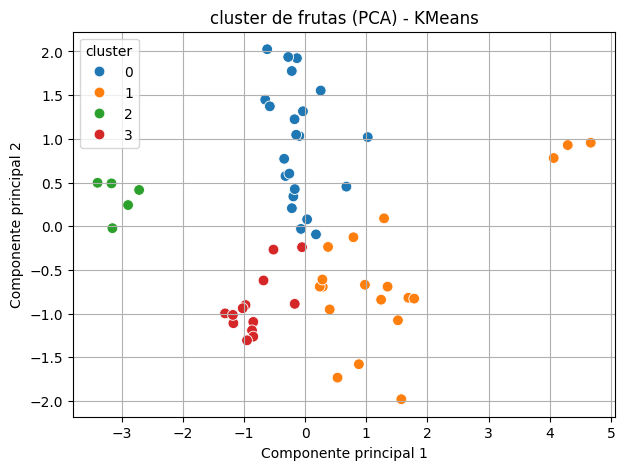

In [64]:
#Visualizacion PCA con 2 componentes
pca = PCA(n_components=2) #PCA con dos componentes
pca_result = pca.fit_transform(x_scaled)
frutas["pca1"] = pca_result[:,0]
frutas["pca2"] = pca_result[:,1]
plt.figure(figsize=(7,5))
sns.scatterplot(data=frutas, x="pca1", y="pca2", hue="cluster", palette="tab10", s=60)
plt.title("cluster de frutas (PCA) - KMeans")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.grid(True)
plt.show()

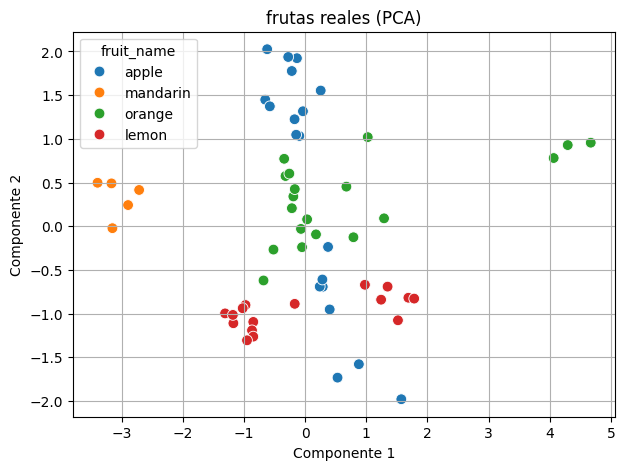

In [65]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=frutas["pca1"],
    y=frutas["pca2"],
    hue=frutas["fruit_name"],
    palette="tab10",
    s=60
)
plt.title("frutas reales (PCA)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.grid(True)
plt.show()

In [66]:
#Analisis descriptivo de cada cluster
resumen = frutas.groupby("cluster")[features].mean().round(2)
print("\nPromedios por cluster:\n", resumen)


Promedios por cluster:
            mass  width  height  color_score
cluster                                    
0        163.00   7.29    7.47         0.83
1        208.63   7.78    8.61         0.70
2         81.20   5.94    4.38         0.80
3        128.31   6.25    8.01         0.72


In [67]:
#K-Means sin PCA (datos originales)
kmeans_original = KMeans(n_clusters=4, random_state=42)
clusters_original = kmeans_original.fit_predict(x_scaled)
frutas ["cluster_original"] = clusters_original

In [68]:
#PCA a 2 componentes
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)
print("Varianza explicada por PC1 y PC2:",
      pca.explained_variance_ratio_)
#K-Means despues de PCA
kmeans_pca = KMeans(n_clusters=4, random_state=42)
clusters_pca = kmeans_pca.fit_predict(x_pca)
frutas["cluster_pca"] = clusters_pca

Varianza explicada por PC1 y PC2: [0.57845054 0.25650171]


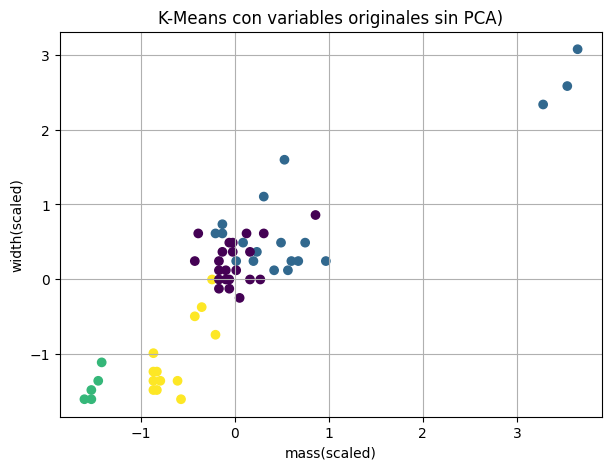

In [69]:
#Visualizacion: clusteres antes de PCA
plt.figure(figsize=(7,5))
plt.scatter(x_scaled[:,0], x_scaled[:,1], c=clusters_original, cmap='viridis')
plt.xlabel("mass(scaled)")
plt.ylabel("width(scaled)")
plt.title("K-Means con variables originales sin PCA)")
plt.grid(True)
plt.show()

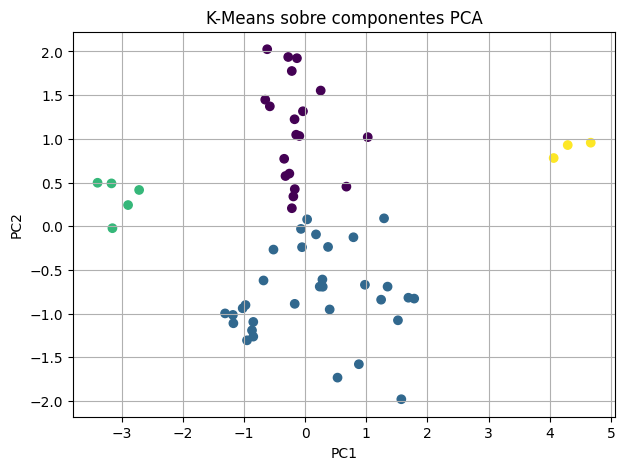

In [70]:
#Visualizacion: clusteres despues de PCA (PC1-PC2)
plt.figure(figsize=(7,5))
plt.scatter(x_pca[:,0], x_pca[:,1], c=clusters_pca, cmap='viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means sobre componentes PCA")
plt.grid(True)
plt.show()

In [71]:
frutas.head()

,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score,cluster,pca1,pca2,cluster_original,cluster_pca
0,1,apple,granny_smith,192,8.4,7.3,0.55,1,1.572169,-1.980044,1,1
1,1,apple,granny_smith,180,8.0,6.8,0.59,1,0.878417,-1.579373,1,1
2,1,apple,granny_smith,176,7.4,7.2,0.60,1,0.529773,-1.732891,1,1
3,2,mandarin,mandarin,86,6.2,4.7,0.80,2,-2.712610,0.414674,2,2
4,2,mandarin,mandarin,84,6.0,4.6,0.79,2,-2.893412,0.242003,2,2


In [72]:
#Generar tablas de conigencia
pd.crosstab(frutas["cluster_original"], frutas["cluster_pca"])

cluster_pca,0,1,2,3
cluster_original,,,,
0,19,3,0,0
1,0,16,0,3
2,0,0,5,0
3,0,13,0,0


In [73]:
score_original = silhouette_score(x_scaled, clusters_original)
score_pca = silhouette_score(x_pca, clusters_pca)
print("Silueta sin PCA:", score_original)
print("Silueta con PCA,", score_pca)

Silueta sin PCA: 0.39419522739862123
Silueta con PCA, 0.4858531414482384


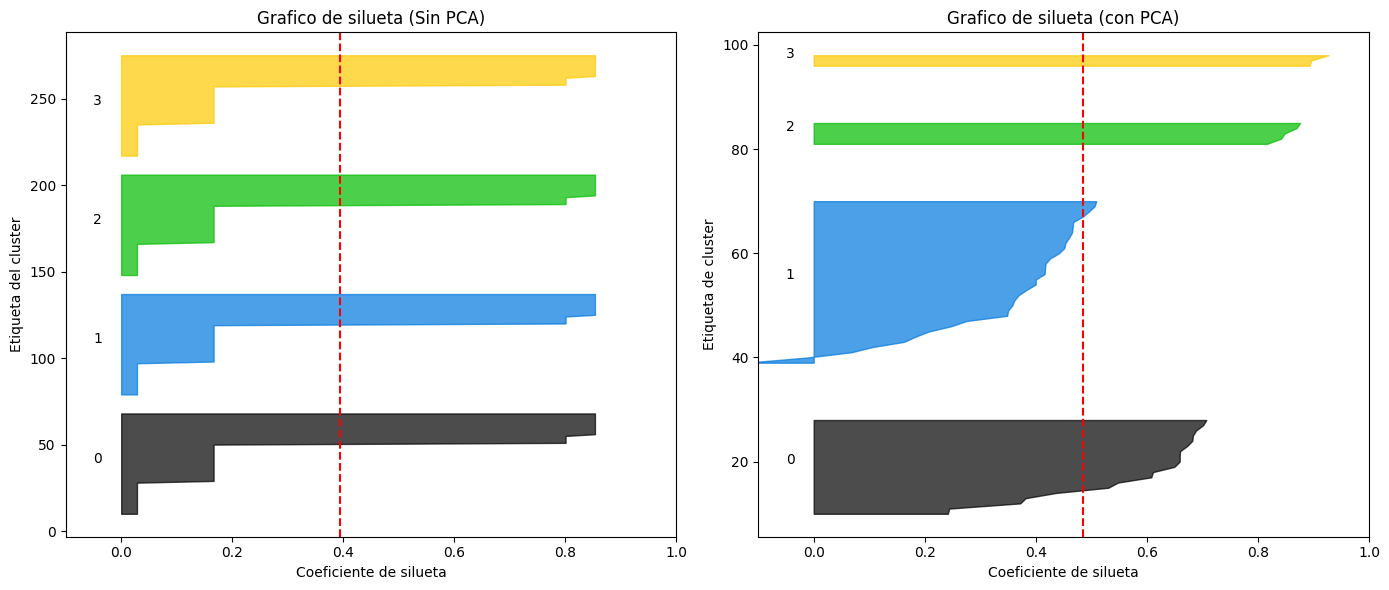

In [79]:
#calcula valores de silueta para cada muestra
silhouette_vals_original = silhouette_samples(x_scaled, clusters_original)
silhouette_vals_pca = silhouette_samples(x_pca, clusters_pca)
#Numero de clusters
n_clusters_original = len(np.unique(clusters_original))
n_clusters_pca = len(np.unique(clusters_pca))
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
#Grafico sin PCA
y_lower = 10
for i in range (n_clusters_original):
  ith_cluster_silhouette_values = silhouette_vals_original[clusters_original --1]
  ith_cluster_silhouette_values.sort()
  size_cluster_i = ith_cluster_silhouette_values.shape[0]
  y_upper = y_lower + size_cluster_i
  color = plt.cm.nipy_spectral(float(i)/ n_clusters_original)
  axes[0].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                        facecolor=color, edgecolor=color, alpha=0.7)
  axes[0].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
  y_lower = y_upper +10
axes[0].axvline(x=np.mean(silhouette_vals_original), color="red", linestyle="--")
axes[0].set_title("Grafico de silueta (Sin PCA)")
axes[0].set_xlabel("Coeficiente de silueta")
axes[0].set_ylabel("Etiqueta del cluster")
axes[0].set_xlim([-0.1, 1])
#Grafico con PCA
y_lower = 10
for i in range (n_clusters_pca):
  ith_cluster_silhouette_values = silhouette_vals_pca[clusters_pca == i]
  ith_cluster_silhouette_values.sort()
  size_cluster_i = ith_cluster_silhouette_values.shape[0]
  y_upper = y_lower + size_cluster_i
  color = plt.cm.nipy_spectral(float(i)/ n_clusters_pca)
  axes[1].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                        facecolor=color, edgecolor=color, alpha=0.7)
  axes[1].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
  y_lower = y_upper +10
axes[1].axvline(x=np.mean(silhouette_vals_pca), color="red", linestyle="--")
axes[1].set_title("Grafico de silueta (con PCA)")
axes[1].set_xlabel("Coeficiente de silueta")
axes[1].set_ylabel("Etiqueta de cluster")
axes[1].set_xlim([-0.1, 1])
plt.tight_layout()
plt.show()

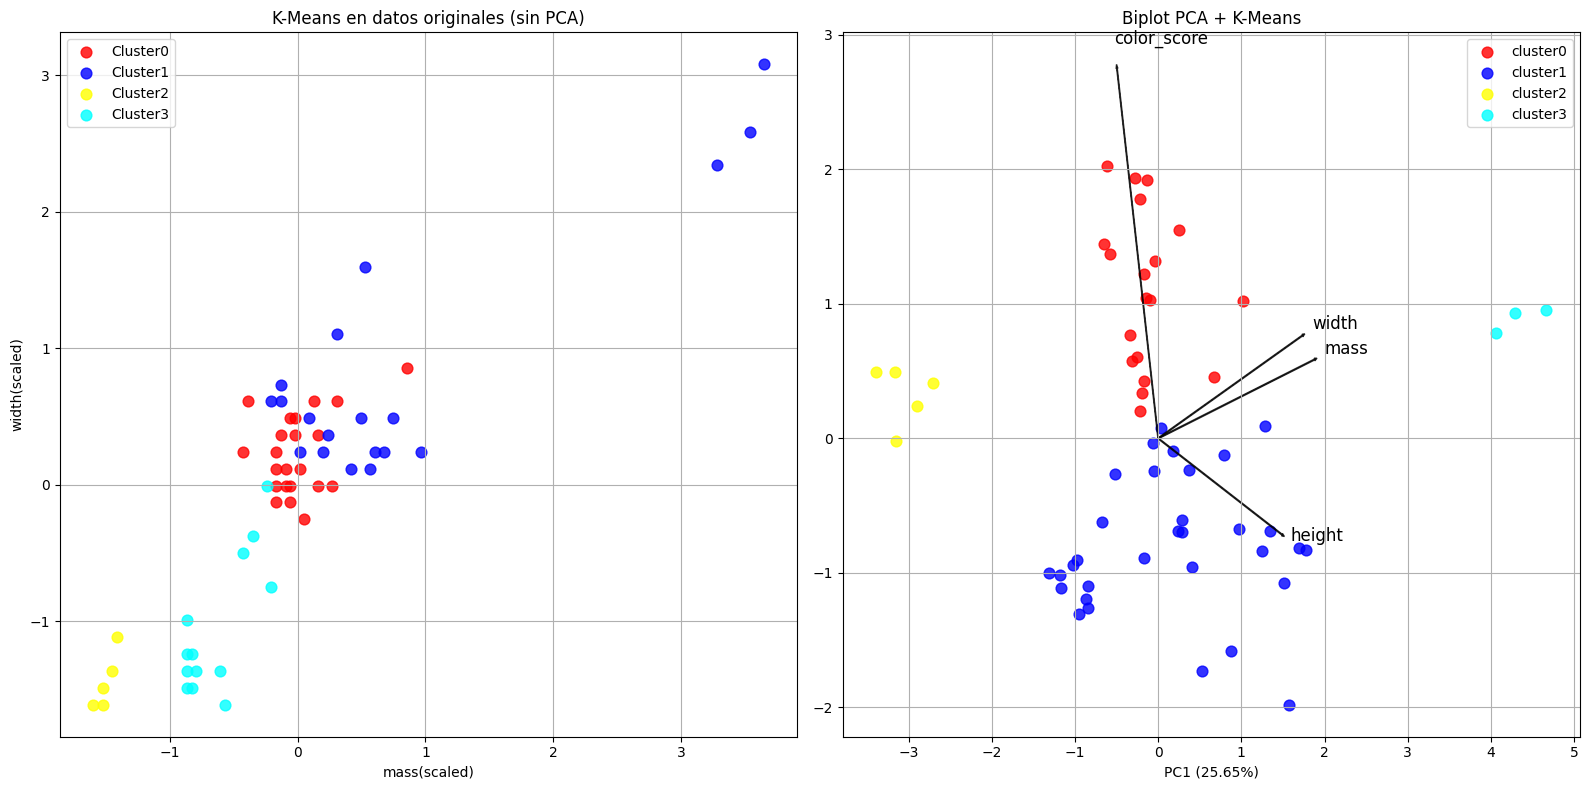

In [85]:
# PCA
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)
loadings = pca.components_.T
variables = x.columns
#K-Means sin PCA
kmeans_original = KMeans(n_clusters=4, random_state=42)
frutas["cluster_original"] = kmeans_original.fit_predict(x_scaled)
#K-Means con PCA
kmeans_pca = KMeans(n_clusters=4, random_state=42)
frutas["cluster_pca"] = kmeans_pca.fit_predict(x_pca)
#colores para clusters de la grafica
palette = ['red', 'blue', 'yellow', 'cyan', 'orange', 'brown']
#subplots para poner graficas de lado a lado
fig, axes = plt.subplots(1,2, figsize=(16,8))
#subplot izquierdo . clusteres sin pca
ax = axes[0] #Grafico en columna 1
for c in sorted(frutas["cluster_original"].unique()):
  ax.scatter(
      x_scaled[frutas["cluster_original"] == c, 0],
      x_scaled[frutas["cluster_original"] == c, 1],
      s=60,
      alpha=0.8,
      color=palette[c],
      label=f"Cluster{c}"
  )
  ax.set_title("K-Means en datos originales (sin PCA)")
  ax.set_xlabel("mass(scaled)")
  ax.set_ylabel("width(scaled)")
  ax.grid(True)
  ax.legend()
#Subplot derecho - biplot con pca + clusteres
ax = axes[1] #Grafico en columna 2
for c in sorted(frutas["cluster_pca"].unique()):
  ax.scatter(
      x_pca[frutas["cluster_pca"] == c, 0],
      x_pca[frutas["cluster_pca"] == c, 1],
      s=60,
      alpha=0.8,
      color=palette[c],
      label=f"cluster{c}"
  )
  #Flechas (loadings)
for i, var in enumerate(variables):
  ax.arrow(
      0,0,
      loadings[i,0]*3,
      loadings[i,1]*3,
      color='black',
      width=0.007,
      alpha=0.8
  )
  ax.text(
      loadings[i,0]*3.2,
      loadings[i,1]*3.2,
      var,
      color="black",
      fontsize=12
  )
ax.set_title("Biplot PCA + K-Means")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

In [88]:
# Aplicamos K-Means con el k elegido (por ejemplo, 5)

kmeans = KMeans(
    n_clusters=5,
    random_state=42
)
clusters = kmeans.fit_predict(x_scaled)
frutas["cluster"] = clusters